# Compute a covariance analogous to Roman Fourier space

The primary example is the Fourier-space **3×2pt** matrix of this project.
3×2pt combines three two-point measurements of one survey: cosmic shear
(source shear × source shear), galaxy–galaxy lensing (lens-galaxy density ×
source shear, called galaxy–shear below) and galaxy clustering (lens density ×
lens density).
Each is measured in 15 **bands**: averages of the angular
power spectrum $C_\ell$ over logarithmic ranges of integer multipoles $\ell$
from 30 to 4000. Band endpoints are inclusive, and each multipole is weighted
by its number of modes, $2\ell+1$. Shear enters through its E-mode spectrum
only, so there is no counterpart of the real-space $\xi_-$ rows. Nine
galaxy–shear pairs, whose lens bins lie far behind their source bins, carry
almost no lensing signal and are excluded, as in the project adapter and
likelihood. The optional real-space calculation describes a different
measurement.

A **covariance matrix** gives the variance of every measured entry on its
diagonal and the joint scatter of every pair of entries off it. This notebook
computes its Gaussian (G), super-sample (SSC), connected non-Gaussian (cNG)
and total parts separately; the section *Compute G, SSC, cNG and their sum*
defines them. It then reads the project's supplied matrix and applies **the
same likelihood mask** to both. The comparison concerns analogous
measurements; it is not a reproduction of the supplied covariance.
No likelihood data file is overwritten and no covariance is installed in C.

| Measurement choice | Value |
| --- | --- |
| Dataset | [data/roman_example.dataset](data/roman_example.dataset) |
| Lens / source bins | 8 / 8 |
| Bands per two-point row | 15, multipoles 30–4000 |
| Generated entries before cuts | 1,485 |
| Entries after the selected likelihood mask | 1,359 |

The forecast uses massless neutrinos and linear galaxy bias. It neglects
lensing magnification of the lens counts and redshift-space distortions
(RSD), and it models the footprint as a spherical cap: one circular patch
with the survey area.

The **Limber approximation** replaces the exact line-of-sight projection of
the three-dimensional power spectrum by a simpler integral. It is accurate
when a bin's radial window is broad compared with the transverse scale and
degrades at low $\ell$ for narrow bins.
Gaussian galaxy–galaxy and galaxy–shear spectra include
non-Limber corrections up to $\ell=1000$ (`nonlimber_lmax` in
[covariance/default.yaml](covariance/default.yaml)); shear–shear remains
Limber.
Intrinsic alignment (IA) of source shapes is off by default; the nonlinear
alignment (NLA) and tidal alignment and tidal torquing (TATT) models can be
selected for the Gaussian part below.

SSC/cNG retain their zero-IA Limber model. SSC uses the isotropic halo-model
response of the power spectrum to a long-wavelength density change, and cNG
the halo trispectrum. Massive-neutrino non-Gaussian terms are not implemented.

These physical choices differ from the supplied likelihood matrices.
Matching their measurement layout does not establish physical or numerical
equivalence.

The [covariance guide](covariance/README.md) explains survey inputs and how to
start Jupyter. The decomposition follows
[Krause & Eifler, Appendix A](https://arxiv.org/abs/1601.05779) and
[Takada & Hu](https://arxiv.org/abs/1302.6994).
Covariance generation is excluded from the default build. Follow the
[project build steps](README.md#computing_covariances): after activating
Cocoa, unset `IGNORE_COSMOLIKE_ROMAN_FOURIER_COVARIANCE` and recompile
this project. Restart the notebook kernel after rebuilding.

In [1]:
import os
from pathlib import Path
import sys

# BLAS stays serial; the compiled CosmoLike loops own the OpenMP workers.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/roman_fourier"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_roman_fourier_interface as ci
import roman_fourier_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov
from cosmolike_notebook_utils.covariance.likelihood import (
    read_likelihood_covariance,
    select_likelihood_entries,
)
from cosmolike_notebook_utils.covariance.forecast import save_forecast

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

## Choose the measurement and numerical settings

The default run computes the project's native measurement once at boost 1.
Set `boosts = [1, 2]` to add the numerical comparison below.
`spaces = ["real", "fourier"]` computes both transformations; the companion
real-space measurement is illustrative and is not compared to the supplied
matrix.

`accuracy_boost` multiplies the internal interpolation refinements and
multipole cutoffs in [covariance/default.yaml](covariance/default.yaml).
The default power tables have 11,993 wavenumber samples; boost 2 uses
23,985 while retaining all original nodes. The loop below reinitializes
these tables for each boost. `integration_accuracy` independently selects
the quadrature: Gauss–Legendre rules of the GNU Scientific Library (GSL)
with 96, 128, 256, 512 or 1,024 precomputed nodes per panel at levels 0–4.
On an M2 Pro laptop, stop Roman quadrature checks at level 3; reserve
level 4 for a server. Keep the scientific bins, cosmology and CAMB inputs
fixed when refining.

The defaults remain **candidate accuracy settings**. Positive definiteness
and a small change in diagonal errors do not establish convergence of all
covariance modes or of Fisher-matrix parameter errors (forecast errors from
the curvature of the likelihood). A comparison with the supplied matrix also
mixes physical choices with numerical differences.

The `gaussian` mapping selects the Gaussian spectra separately from numerical
accuracy. Use `ia="NLA", A1=0.6` for an illustrative constant NLA amplitude,
or `ia="TATT", A1=0.6, A2=0.2, B_TA=0.5` for TATT. A list gives one amplitude
per source bin. TATT B modes enter real-space shear covariance; the Fourier
rows use E modes only. These choices change only the Gaussian part: SSC and
cNG, including the spectra in the SSC survey-mean correction, keep zero IA
and the Limber approximation.


In [2]:
boosts = [1]
spaces = ['fourier']
gaussian = {"nonlimber": True, "ia": "none"}
settings = survey.configuration(
    accuracy_boost=boosts[0], gaussian=gaussian,
)
dataset = project/"data/roman_example.dataset"

# These are physical assumptions, not inferred from normalized n(z) columns.
for key in (
    "area_deg2",
    "lens_density_arcmin2",
    "source_density_arcmin2",
    "sigma_e_component",
    "bias",
    "cosmology",
    "accuracy_parameters",
    "gaussian",
):
    print(key, settings[key])

camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)


def progress(stage, elapsed):
    """Report completed stages of this calculation, in seconds."""
    print(f"{elapsed:8.2f} s  {stage}")

area_deg2 2415.0
lens_density_arcmin2 [5.1625, 5.1625, 5.1625, 5.1625, 5.1625, 5.1625, 5.1625, 5.1625]
source_density_arcmin2 [5.1625, 5.1625, 5.1625, 5.1625, 5.1625, 5.1625, 5.1625, 5.1625]
sigma_e_component [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
bias [1.18, 1.4, 1.55, 1.71, 1.9, 2.15, 2.52, 2.44]
cosmology {'omegam': 0.3, 'omegab': 0.04, 'H0': 67.32, 'ns': 0.96605, 'As_1e9': 2.1, 'w': -1.0, 'w0pwa': -1.0, 'mnu': 0.0, 'AccuracyBoost': 1.0, 'CLAccuracyBoost': 1.0, 'CAMBAccuracyBoost': 1.0, 'kmax': 20.0, 'k_per_logint': 20, 'non_linear_emul': 2, 'lens_potential_accuracy': 1.0, 'halofit_version': 'takahashi'}
accuracy_parameters {'non_gaussian_accuracyboost': 1, 'window_accuracyboost': 1, 'core_accuracyboost': 1, 'power_accuracyboost': 8, 'nonlimber_accuracyboost': 2, 'ell_max': 100000, 'mask_ell_max': 32768, 'ng_ell_intervals': 127, 'response_step': 5e-05, 'nonlimber_lmax': 1000, 'integration_accuracy': 0}
gaussian {'nonlimber': True, 'ia': 'none', 'A1': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

## See the 1h, 2h, 3h and 4h matter trispectra

The **trispectrum** describes the connected four-point correlation of the
matter density in Fourier space. The **halo model** assumes that all matter
sits in halos, so the four density factors can live in one, two, three or
four halos, and the model separates their contributions:

| Term | Where the four density factors live |
| --- | --- |
| 1h | All four in one halo. |
| 2h | Two halos, partitioned as 1+3 or 2+2 factors. Both partitions enter. |
| 3h | Three halos, partitioned as 2+1+1 factors. |
| 4h | Four different halos. |

For power-spectrum covariance the wavevectors form
$\mathbf{k},-\mathbf{k},\mathbf{q},-\mathbf{q}$.
The helper averages over the angle between $\mathbf{k}$ and $\mathbf{q}$
in the transverse plane.
Below, choose one redshift and plot the diagonal $q=k$:
$\overline{T}=T_{1h}+T_{2h}^{(1+3)}+T_{2h}^{(2+2)}+T_{3h}+T_{4h}$.
This is a **matter trispectrum before survey projection**, not a diagonal
of the project's covariance matrix. SSC and Gaussian covariance are separate.

The example uses the initialized cosmology, mass panels and integration
level above. Its 65 wavenumbers sample the plot; they do not change the
integration rule. Internally CosmoLike measures lengths in $c/H_0$.
Convert the input $k$ from $h/\mathrm{Mpc}$ and the output trispectrum
back to $(\mathrm{Mpc}/h)^9$ for the figure.

`halo_terms` retains every unordered $(k,q)$ pair, including off-diagonal
pairs. `T2h_13` and `T2h_22` remain separate arrays; only the plotted 2h
curve combines them. The signed logarithmic y axis preserves negative
contributions and is linear within $|\overline{T}|<1\,(\mathrm{Mpc}/h)^9$.
Changing `halo_redshift` below explores another epoch without rerunning CAMB.


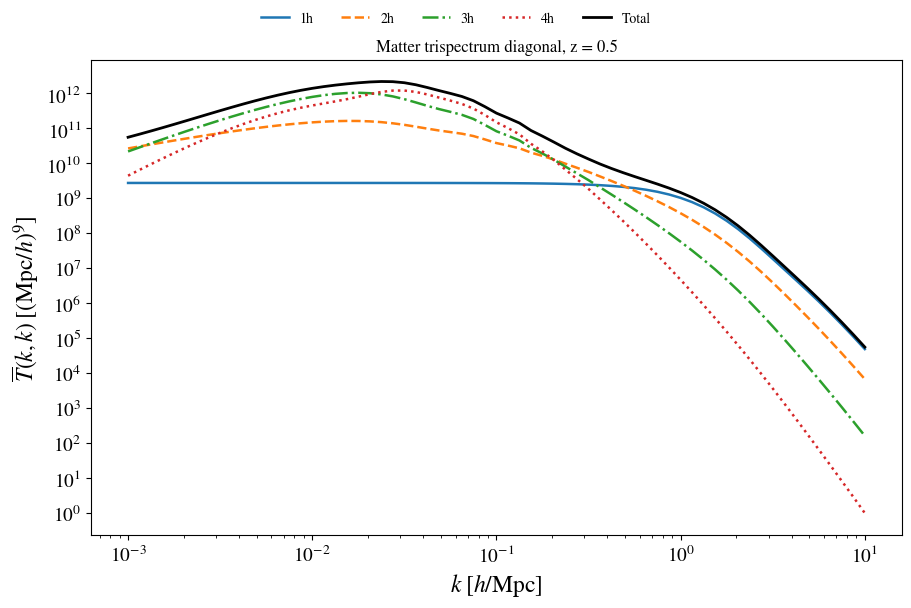

In [3]:
halo_redshift = 0.5
halo_scale_factor = 1.0/(1.0+halo_redshift)
k_hmpc = np.geomspace(start=1.e-3, stop=10.0, num=65)

# c/H0 is 2997.92458 Mpc/h: the factor h is already in the length unit.
# A trispectrum has nine powers of length, whereas power has three.
cover_h0_mpc_over_h = 2997.92458
k_core = k_hmpc*cover_h0_mpc_over_h
halo_terms = cov.halo_trispectrum(
    interface=ci,
    a=halo_scale_factor,
    k=k_core,
    lnm_edges=settings["lnm_edges"],
    accuracy_boost=settings["accuracy_boost"],
    mnu=settings["cosmology"]["mnu"],
    integration_accuracy=settings["integration_accuracy"],
)
terms_mpc_over_h9 = halo_terms["terms"]*cover_h0_mpc_over_h**9

# The five rows distinguish the two possible two-halo partitions.
# Every row uses the same triangular ordering of wavenumber pairs.
T1h = terms_mpc_over_h9[0]
T2h_13 = terms_mpc_over_h9[1]
T2h_22 = terms_mpc_over_h9[2]
T3h = terms_mpc_over_h9[3]
T4h = terms_mpc_over_h9[4]
T2h = T2h_13+T2h_22

# Equal pair indices select q=k, in the order of the original k grid.
diagonal_pairs = halo_terms["first"] == halo_terms["second"]
halo_diagonal = {
    "1h": T1h[diagonal_pairs],
    "2h": T2h[diagonal_pairs],
    "3h": T3h[diagonal_pairs],
    "4h": T4h[diagonal_pairs],
}
pcov.plot_trispectrum_terms(
    k_hmpc=k_hmpc,
    components=halo_diagonal,
    redshift=halo_redshift,
)


## Compute G, SSC, cNG and their sum

G describes covariance made from pairs of two-point spectra, including
catalog shot noise ($1/n$, from counting discrete galaxies) and shape noise
($\sigma_e^2/n$, from random intrinsic ellipticities, with $\sigma_e$ per
component), where $n$ is the number density per steradian. SSC couples
measurements through a background density fluctuation larger than the
footprint. cNG is the remaining connected four-point contribution in the
adopted halo model.

Bands are consecutive within each observable row. Each source pair has one
E-mode row, and integer multipoles inside a band are weighted by $2\ell+1$.
The Fourier likelihood evaluates its mean spectrum at logarithmic band
centers; the generated covariance instead averages integer modes within
bands. It is therefore an analogous bandpower calculation.

The covariance of measured spectra $AB$ and $CD$ needs the spectra $AC$, $BD$,
$AD$ and $BC$, so each computation retains internal cross-bin spectra even
when the corresponding observable is absent from the measured vector. The
loop below changes only numerical resolution, and stores all physical
components at each requested boost.

In [4]:
# Each space uses its own projection. Changing the boost refines tables
# while preserving cosmology, observable ordering and measured bins.
results = {}
for space in spaces:
    if space not in ['real', 'fourier']:
        raise ValueError("Choose a measurement space supported by this adapter")
    results[space] = {}
    for boost in boosts:
        refined = dict(settings)
        refined.update(cov.covariance_accuracy(
            accuracy_boost=boost, **settings["accuracy_parameters"],
        ))
        # Reinstall the power tables at this boost, so their k grid
        # is refined along with the covariance integration tables.
        camb_tables = survey.initialize(interface=ci, settings=refined)
        ci.set_omp_threads(n=8)
        print(space, "accuracy boost", boost)
        results[space][boost] = survey.compute(
            interface=ci, settings=refined, space=space, progress=progress,
        )

native_space = 'fourier'
forecast = results[native_space][boosts[-1]]
print("Full covariance shape:", forecast["total"].shape)

fourier accuracy boost 1


    1.86 s  all_pairs_gaussian_spectra
    1.88 s  angular_and_mask_geometry
    1.96 s  gaussian_blocks
    1.97 s  observable_signal


    2.29 s  Matter shell 1/672


    6.02 s  Matter shell 33/672


    9.76 s  Matter shell 65/672


...

   72.47 s  Matter shell 577/672


   76.64 s  Matter shell 609/672


   80.79 s  Matter shell 641/672


   84.74 s  shared_halo_response_and_trispectrum


   84.98 s  ssc_and_connected_projection
   84.99 s  total
Full covariance shape: (1485, 1485)


## Apply the project's likelihood cuts

**Scale cuts** remove measurements that the model is not trusted to predict.
Here the mask keeps every cosmic-shear band and removes the two highest
galaxy–shear and clustering bands, where the linear galaxy-bias model is not
trusted.
A cut removes a measurement, so the same selection must act on both axes
(rows and columns) of G, SSC, cNG and their sum. The saved `indices` preserve
the original file positions after compaction. Probe labels refer to
contiguous groups in the uncut likelihood vector, including any measured-pair
exclusions.

The supplied matrix is a text file in the format of CosmoCov, the earlier
CosmoLike covariance code. The reader adds its Gaussian and combined
non-Gaussian columns and does not guess how the combined column divides into
SSC and cNG.

The first figure compares **correlation matrices**,
$r_{ij}=C_{ij}/\sqrt{C_{ii}C_{jj}}$, each normalized by its own diagonal. Its
title names matrix triangles: the newly computed total fills the lower
triangle (row > column) and the supplied total the upper one. The image puts
entry 0 at the bottom left, so the computed total appears in the upper-left
half of the picture and the supplied total in the lower-right half. The
component maps divide each part by the total diagonal,
$C^{\rm part}_{ij}/\sqrt{C^{\rm tot}_{ii}C^{\rm tot}_{jj}}$. A matrix is
**positive definite** when every linear combination of its measurements has
positive variance, that is, when every eigenvalue is positive; the printout
reports this for both totals. Differences between the two matrices are
**not** a numerical convergence test.

The split-triangle layout follows [Friedrich et al., Fig. 6](https://arxiv.org/abs/2012.08568).
Component maps adapt [Barreira, Krause & Schmidt, Fig. 1](https://arxiv.org/abs/1807.04266).

Supplied file size: 1485
Retained comparison size: 1359
Mask: roman_example.mask


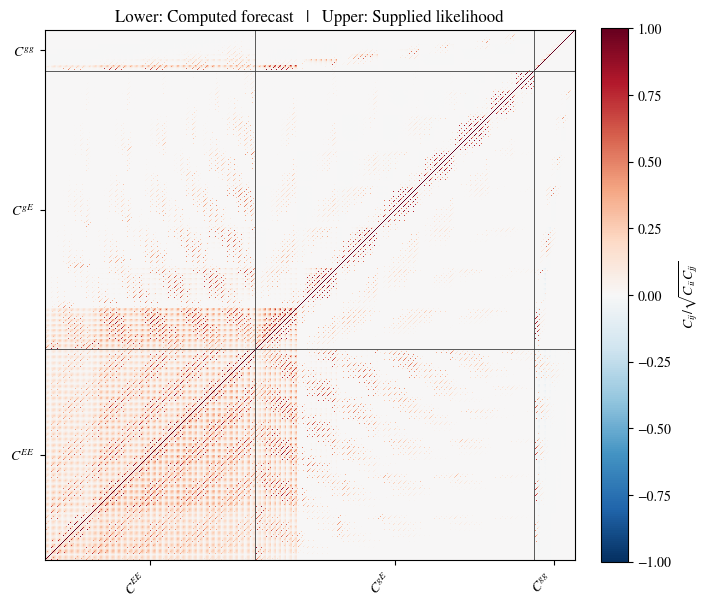

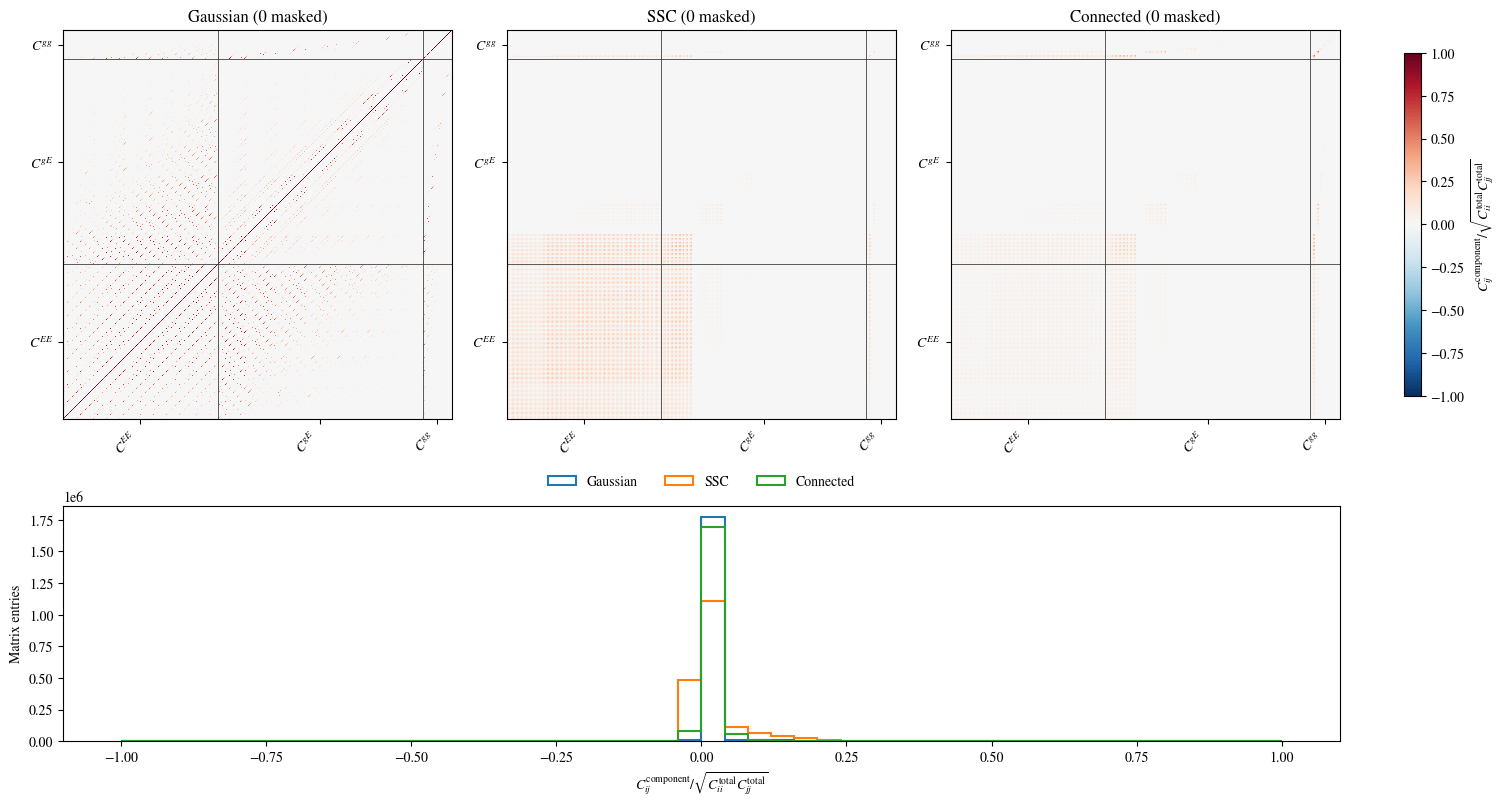

total positive definite: True minimum correlation eigenvalue: 0.00025129750065518364


supplied positive definite: True minimum correlation eigenvalue: 0.0002175560225385068


In [5]:
supplied = read_likelihood_covariance(dataset=dataset)
block_sizes = [540, 825, 120]
block_labels = ['$C^{EE}$', '$C^{gE}$', '$C^{gg}$']
selected = select_likelihood_entries(
    forecast=forecast,
    supplied=supplied,
    block_sizes=block_sizes,
    block_labels=block_labels,
)
print("Supplied file size:", supplied["file_size"])
print("Retained comparison size:", len(selected["indices"]))
print("Mask:", Path(supplied["mask_file"]).name)

pcov.plot_correlation(
    covariance=selected["total"],
    covariance_ref=selected["supplied"],
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    labels=("Computed forecast", "Supplied likelihood"),
)
pcov.plot_covariance_components(
    total=selected["total"],
    components={
        "Gaussian": selected["gaussian"],
        "SSC": selected["ssc"],
        "Connected": selected["cng"],
    },
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    normalization="diagonal",
)

for label in ("total", "supplied"):
    modes = cov.covariance_modes(matrix=selected[label])
    print(label, "positive definite:", modes["positive_definite"],
          "minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])

## See what the likelihood mask removed

`select_likelihood_entries` keeps the entries whose mask flag is 1 and stores
their original positions in `selected["indices"]`. Each row of the uncut
vector holds its bands consecutively, so the band of an entry is its index
modulo the number of bands. The next cell lists the band centers that lost an
entry and counts the retained entries of each probe.
For this dataset it should report 126 removed entries: the bands centered near
$\ell=2452$ and 3398 of all 55 galaxy–shear and 8 clustering rows.

In [ ]:
# Each row of the uncut vector holds its bands consecutively, so the band
# number of an entry is its index modulo the number of bands.
nband = len(forecast["coordinate"])
removed = np.flatnonzero(a=np.logical_not(supplied["mask"]))
removed_bands = np.unique(ar=removed % nband)
print("Entries removed by the mask:", len(removed))
print("Band centers with removed entries:", forecast["coordinate"][removed_bands])
start = 0
for count, label in zip(block_sizes, block_labels):
    kept = np.count_nonzero(a=supplied["mask"][start:start+count])
    print(f"{label}: {kept} of {count} entries kept")
    start += count

## Compare standard deviations, not only correlations

A correlation matrix divides out every variance, so the split-triangle figure
cannot show whether two matrices predict the same error bars. Without a
reference matrix, `plot_covariance_diagonal` draws the standard deviation
$\sigma_i=\sqrt{C_{ii}}$ of each band. The next two cells select every band of
the first row of each probe, before cuts: cosmic shear S1–S1, galaxy–shear
L1–S1 and clustering L1–L1 (S and L number the source and lens bins from 1).
They compare the Gaussian part, the G+SSC+cNG total and the supplied matrix.
The gap between the Gaussian and total curves shows where SSC and cNG add
variance, mostly at intermediate and high $\ell$; where shot or shape noise
dominates the Gaussian part, the gap closes again. The supplied curve differs
because that matrix was computed with its own survey and physical
assumptions.

In [ ]:
# Correlations divide out every variance, so compare standard deviations.
# Select every band of the first row of each probe, before scale cuts;
# column 0 of forecast["rows"] holds the probe code of each row.
nband = len(forecast["coordinate"])
entries = []
for probe in (0, 2, 3):
    first_row = np.flatnonzero(a=forecast["rows"][:, 0] == probe)[0]
    entries.extend(range(first_row*nband, (first_row+1)*nband))
# np.ix_ pairs the same entries on both axes: a square block of the matrix.
block = np.ix_(entries, entries)

In [ ]:
# theta_arcmin only places the curves on the horizontal axis; here it
# receives the band centers in multipoles.
sigma_matrices = {
    "Gaussian": forecast["gaussian"][block],
    "G+SSC+cNG": forecast["total"][block],
    "Supplied total": supplied["total"][block],
}
pcov.plot_covariance_diagonal(
    theta_arcmin=forecast["coordinate"],
    covariances=sigma_matrices,
    panel_labels=["$C^{EE}$ S1-S1", "$C^{gE}$ L1-S1", "$C^{gg}$ L1-L1"],
    coordinate_label="$\\ell$",
)

## Find the smallest correlation mode

`covariance_modes` divides each entry by its standard deviation and returns
the eigenvalues of the resulting correlation matrix. An eigenvalue is the
variance of one linear combination of these standardized measurements: 1 is
the variance of a single entry, and a value near zero marks a combination
that barely fluctuates because its measurements are nearly redundant. The
ratio of the largest to the smallest eigenvalue, the condition number, bounds
how much relative errors can grow when the matrix is inverted.

The first cell repeats the test for the Gaussian part and for the supplied
matrix. The second finds which entries form the smallest mode and prints the
four largest weights with their rows: probe 0 is cosmic shear, 2 galaxy–shear
and 3 clustering;
fields 0–7 are the lens bins L1–L8 and fields 8–15 the source bins S1–S8;
band 0 is the lowest band.

In the archived boost-1 run the smallest eigenvalue of the computed total is
about $2.5\times10^{-4}$. It lies in the lowest band, $\ell=30$–41, and combines
cosmic-shear spectra among S6–S8 with galaxy–shear spectra that mostly
involve S7. These source bins lie behind nearly the same foreground matter,
so their convergence maps (the projected matter density that the shear measures) are
strongly correlated: adjacent bins have correlation coefficients of about
0.98–0.99 at $\ell\approx35$, and shape noise is only 2–4% of their signal
there. For two maps with correlation coefficient $r$ and noise-to-signal ratio
$N/C$, one combination of their three band powers has a relative variance of
order $(1-r+N/C)^2$. The Gaussian part alone has the same mode, and the
supplied matrix a similar one, near $2.2\times10^{-4}$: it is a property of
the measurement, not a numerical failure. Inversion weights this direction
by $1/\lambda\approx4\times10^3$ in $\chi^2$.

In [ ]:
# Correlation eigenvalues are dimensionless: 1 is the variance of a single
# standardized entry. The Gaussian part shows whether a small mode exists
# before SSC and cNG; the supplied matrix, whether another calculation shares it.
for label in ("total", "gaussian", "supplied"):
    modes = cov.covariance_modes(matrix=selected[label])
    eigenvalues = modes["correlation_eigenvalues"]
    condition_number = eigenvalues[-1]/eigenvalues[0]
    print(f"{label}: smallest {eigenvalues[0]:.2e}, largest {eigenvalues[-1]:.2e},"
          f" condition number {condition_number:.1e}")

In [ ]:
# covariance_modes returns eigenvalues only; eigh also returns the unit
# eigenvectors, one per column, in the same ascending order.
deviation = np.sqrt(np.diag(v=selected["total"]))
correlation = selected["total"]/np.outer(a=deviation, b=deviation)
correlation_eigenvalues, eigenvectors = np.linalg.eigh(a=correlation)
print("Smallest correlation eigenvalue:", correlation_eigenvalues[0])
# The squared components of a unit vector sum to one: they are weights.
weight = eigenvectors[:, 0]**2
nband = len(forecast["coordinate"])
# Sorting the negated weights lists the largest weights first.
for position in np.argsort(a=-weight)[:4]:
    entry = selected["indices"][position]
    probe, first_field, second_field = forecast["rows"][entry//nband]
    print(f"weight {weight[position]:.2f}: probe {probe}, fields {first_field}"
          f" and {second_field}, band {entry % nband}")

## Check changes with accuracy boost

With two or more boosts, the next cell compares the *computed* matrices after
the same likelihood cuts. The highest tested boost is the comparison
reference, $C_{\rm ref}$. The generalized eigenvalues $\lambda$ solve
$C_b v=\lambda C_{\rm ref}v$, where $C_b$ is the matrix at boost $b$. For every
linear combination $v$ of retained measurements, the variance ratio
$v^{\mathsf T}C_bv/v^{\mathsf T}C_{\rm ref}v$ lies between the smallest and the
largest $\lambda$. The reported maximum departure from one is a fraction; 0.01
means 1%.

The error-bar panel selects the first source auto-correlation. It shows the
percent change of $\sqrt{C_{ii}}$ relative to the highest boost. This illustrates
why convergence needs more than diagonal agreement. Refine quadrature separately
at fixed boost, and eventually check marginalized Fisher errors and the Figure
of Merit, which is proportional to the inverse area of a two-parameter error
ellipse such as $w_0$–$w_a$. No matrix here has its eigenvalues clipped or its
diagonal repaired.

In [6]:
if len(boosts) == 1:
    print("Set boosts = [1, 2] above and rerun to compare numerical accuracy.")
else:
    for boost in boosts:
        current = select_likelihood_entries(
            forecast=results[native_space][boost],
            supplied=supplied,
            block_sizes=block_sizes,
            block_labels=block_labels,
        )
        change = cov.compare_covariances(
            matrix=current["total"], reference=selected["total"],
        )
        print(boost, "maximum fractional variance change:",
              change["maximum_fractional_variance_change"])

    # The first observable is the first source auto-correlation, with
    # all its angular bins or Fourier bands consecutive in the full vector.
    nbin = 15
    reference = forecast["total"][:nbin, :nbin]
    curves = {}
    for boost in boosts[:-1]:
        curves[f"Boost {boost} / {boosts[-1]}"] = (
            results[native_space][boost]["total"][:nbin, :nbin]
        )
    coordinate = forecast["coordinate"]
    pcov.plot_covariance_diagonal(
        theta_arcmin=coordinate,
        covariances=curves,
        panel_labels=['$C^{EE}$'],
        covariance_ref=reference,
        coordinate_label='$\\ell$' if native_space == "fourier" else '$\\theta\\;[\\mathrm{arcmin}]$',
    )

Set boosts = [1, 2] above and rerun to compare numerical accuracy.


## Inspect the C++ notebook interface

The compiled wrappers take vectors, matrices and cubes (three-dimensional
arrays) of Armadillo, a C++ linear-algebra library, with named physical axes.
Python converts NumPy inputs into Armadillo arrays owned by the C++ side, so
the notebook copies are intentional. Whole Gaussian matrices and individual
projection, halo and response components are available for independent
experiments. The help text gives dimensions and units.

In [7]:
help(ci.covariance_gaussian_fourier)
help(ci.covariance_project)
help(ci.covariance_halo_response)

Help on built-in function covariance_gaussian_fourier in module cosmolike_roman_fourier_interface:

covariance_gaussian_fourier(...) method of builtins.PyCapsule instance
    covariance_gaussian_fourier(spectra: object, noise: object, pairs: object, operators: object, ell_min: int, area_sr: float) -> Numpy.ndarray[numpy.float64]
    
    Compute a Gaussian bandpower matrix from supplied field spectra.
    
    spectra[ell,field,field] contains observed signal on consecutive integer
    multipoles starting at ell_min>=0. noise[field] is independent white
    shot/shape power. pairs[observable,2] contains field IDs (A,B).
    operators[band,ell] supplies normalized band weights; the supplied bands
    may overlap. area_sr is the common survey area in steradians.
    Use float64 arrays and int32 pairs. Internal crossed spectra
    are required even when excluded from the measured bandpower vector.
    
    Returns an owned symmetric [nobservable*nband,nobservable*nband] matrix,
    with b

## Save the calculation

The archives retain each physical component, ordering, physical assumptions and
resolved accuracy settings. The separate likelihood-selection archive contains
the compact matrices, original entry indices and the supplied total used in the
plot. Only files in `covariance/` are written; the supplied files in `data/`
remain unchanged. Running this cell again replaces the computed archives. The
last section reads the native-space archive back.

In [8]:
for space in spaces:
    save_forecast(
        result=results[space][boosts[-1]],
        filename=project/"covariance"/f"forecast_{space}.npz",
    )
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)
np.savez(
    file=project/"covariance/forecast_likelihood_selection.npz",
    **selected,
    dataset=str(dataset.relative_to(project)),
    accuracy_boost=boosts[-1],
)
print("Saved covariance components and likelihood selection.")

Saved covariance components and likelihood selection.


## Read the saved archive back

`save_forecast` writes NumPy arrays and two JSON text values, `settings_json`
and `stages_json`. The archive therefore loads with `allow_pickle=False`,
which refuses pickled Python objects that could run code while loading. The
next cell reloads the native-space archive, checks that its total equals the
matrix in memory exactly, and prints the resolved settings that produced it.
`forecast_likelihood_selection.npz` loads the same way; its arrays carry the
key names of `selected`, plus `dataset` and `accuracy_boost`.

In [ ]:
import json

# allow_pickle=False refuses pickled Python objects, which could run code
# while loading; save_forecast writes plain arrays and JSON text only.
filename = project/"covariance"/f"forecast_{native_space}.npz"
with np.load(file=filename, allow_pickle=False) as archive:
    saved_total = archive["total"]
    # settings_json is one text value; json.loads rebuilds the mapping.
    saved_settings = json.loads(str(archive["settings_json"]))
print("Saved total equals the computed total:",
      np.array_equal(a1=saved_total, a2=forecast["total"]))
print("Saved accuracy boost:", saved_settings["accuracy_boost"])
print("Saved Gaussian model:", saved_settings["gaussian"])